In [1]:
import sys
import os
import pandas as pd
import importlib

# Proje kök dizinini Python arama yolunda en üste al
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root) # Proje kök dizinini arama yolunun en üstüne ekleyelim

# utils.py içindeki fonksiyonları import edelim
import src.utils as utils
importlib.reload(utils) # utils modülünü yeniden yükleyelim, böylece yapılan değişiklikler geçerli olur
chronogical_split = utils.chronogical_split

# EDA aşamasındaki veriyi yükleyelim
data_path = '../data/processed/nrel_data_5cities_filtered.parquet'
print(f"Veri dosyası: {data_path}...")
df = pd.read_parquet(data_path)
print(f"Veri başarıyla yüklendi. Toplam kayıt sayısı: {len(df)}")

# Kronolojik olarak veriyi bölerek eğitim ve test setlerini oluşturalım
train_df, val_df, test_df = chronogical_split(df, datetime_col ='datetime')

# 4. TEST VE SAĞLAMALAR (Hata yapıp yapmadığımızı buradan göreceğiz)
print("\n--- Veri Bölünme Raporu ---")
print(f"Eğitim Seti (Train) : {len(train_df):,} satır | Başlangıç: {train_df.index.min()} | Bitiş: {train_df.index.max()}")
print(f"Doğrulama Seti (Val): {len(val_df):,} satır  | Başlangıç: {val_df.index.min()} | Bitiş: {val_df.index.max()}")
print(f"Test Seti (Test)    : {len(test_df):,} satır  | Başlangıç: {test_df.index.min()} | Bitiş: {test_df.index.max()}")

# Şehir bazında dağılım kontrolü
print("\n--- Eğitim Setindeki Şehir Dağılımı ---")
print(train_df['City'].value_counts())

Veri dosyası: ../data/processed/nrel_data_5cities_filtered.parquet...
Veri başarıyla yüklendi. Toplam kayıt sayısı: 438000

--- Veri Bölünme Raporu ---
Eğitim Seti (Train) : 262,800 satır | Başlangıç: 0 | Bitiş: 262799
Doğrulama Seti (Val): 87,600 satır  | Başlangıç: 0 | Bitiş: 87599
Test Seti (Test)    : 87,600 satır  | Başlangıç: 0 | Bitiş: 87599

--- Eğitim Setindeki Şehir Dağılımı ---
City
Denver_CO     52560
Miami_FL      52560
Boston_MA     52560
Phoenix_AZ    52560
Seattle_WA    52560
Name: count, dtype: int64


In [2]:
import src.utils as utils
importlib.reload(utils) # utils.py içindeki yeni fonksiyonu algılasın

# Modelin kullanacağı özellikleri ve hedefi belirleyelim
TARGET_COL = 'GHI_Filtered' # Hedef değişkenimiz GHI_Filtered olacak
FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 
    'Relative Humidity', 'Wind Speed', 'Cloud Type', 
    'Clearness_Index', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# 96 adım geçmişine bak (48 saat), 24 adım geleceği tahmin et (12 saat)
LOOK_BACK = 96
LOOK_FORWARD = 24

print("1. Eğitim (Train) seti hazırlanıyor...")
X_train, y_train = utils.create_sliding_features(train_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Train seti hazırlandı. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print("\n2. Doğrulama (Validation) seti hazırlanıyor...")
X_val, y_val = utils.create_sliding_features(val_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Validation seti hazırlandı. X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print("\n3. Test seti hazırlanıyor...")
X_test, y_test = utils.create_sliding_features(test_df, feature_cols=FEATURE_COLS, target_col=TARGET_COL, look_back=LOOK_BACK, horizon=LOOK_FORWARD)
print(f"Test seti hazırlandı. X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

import torch
from torch.utils.data import TensorDataset, DataLoader

print("\n--- Numpy Dizisinden Tensörler oluşturuluyor ---")
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Batch size yani tanımlayalım
BATCH_SIZE = 128

print("\n--- DataLoader'lar oluşturuluyor ---")
# Eğitim seti için Shuffle = True yaparak veriyi karıştıralım ki ezberlemeyi önleyelim
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Doğrulama ve test setleri için Shuffle = False yaparak sıralı kalmasını sağlayalım
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_loader)} batch")
print(f"Validation DataLoader: {len(val_loader)} batch")
print(f"Test DataLoader: {len(test_loader)} batch")

1. Eğitim (Train) seti hazırlanıyor...
Train seti hazırlandı. X_train shape: (262205, 96, 11), y_train shape: (262205, 24)

2. Doğrulama (Validation) seti hazırlanıyor...
Validation seti hazırlandı. X_val shape: (87005, 96, 11), y_val shape: (87005, 24)

3. Test seti hazırlanıyor...
Test seti hazırlandı. X_test shape: (87005, 96, 11), y_test shape: (87005, 24)

--- Numpy Dizisinden Tensörler oluşturuluyor ---

--- DataLoader'lar oluşturuluyor ---
Train DataLoader: 2049 batch
Validation DataLoader: 680 batch
Test DataLoader: 680 batch


In [3]:
import torch
import shap
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Proje yollarını ayarla
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path: sys.path.insert(0, project_root)

from src.models.patchtst import CustomPatchTST
from src.models.autoformer import CustomAutoFormer

device = torch.device("cpu")
feature_names = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 
    'Relative Humidity', 'Wind Speed', 'Cloud Type', 
    'Clearness_Index', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# Modelleri yükle
model_patch = CustomPatchTST(seq_len=96, pred_len=24, enc_in=11).to(device)
model_patch.load_state_dict(torch.load('../outputs/models/patchtst_solar_model.pth', map_location=device))

model_autoformer = CustomAutoFormer(seq_len=96, pred_len=24, enc_in=11).to(device)
model_autoformer.load_state_dict(torch.load('../outputs/models/autoformer_solar_model.pth', map_location=device))

print("Modeller başarıyla yüklendi!")

Modeller başarıyla yüklendi!


In [4]:
def get_model_shap_ready_short_term(model, data_2d):
    # Veriyi 3D'ye çevir
    data_3d = np.repeat(data_2d[:, np.newaxis, :], 96, axis=1)
    data_tensor = torch.tensor(data_3d, dtype=torch.float32).to(device)
    
    model.eval()
    preds_list = []
    
    # 💥 RAM PATLAMASINI ÖNLEYEN KISIM (Mini-Batching)
    # Gelen binlerce senaryoyu 64'lük küçük paketler halinde modele sokuyoruz
    chunk_size = 64 
    with torch.no_grad():
        for i in range(0, len(data_tensor), chunk_size):
            batch_tensor = data_tensor[i : i + chunk_size]
            batch_preds = model(batch_tensor).cpu().numpy()
            
            # Sadece 2. adımı (Kısa vade / 1 saat sonrası) alıp listeye ekliyoruz
            preds_list.append(batch_preds[:, 2]) 
            
    # Tüm küçük paketlerin sonuçlarını tek bir uzun liste olarak birleştirip SHAP'a veriyoruz
    return np.concatenate(preds_list, axis=0)

# SHAP için arka plan verisi hazırlayalım
background_small = X_test[np.random.choice(X_test.shape[0], 50, replace=False)]
background_2d = np.mean(background_small, axis=1)

In [5]:
print("SHAP hesaplanıyor...")
explainer_auto = shap.KernelExplainer(lambda d: get_model_shap_ready_short_term(model_autoformer, d), background_2d)
explainer_patch = shap.KernelExplainer(lambda d: get_model_shap_ready_short_term(model_patch, d), background_2d)

shap_auto = explainer_auto.shap_values(background_2d, nsamples=400)
shap_patch = explainer_patch.shap_values(background_2d, nsamples=400)

SHAP hesaplanıyor...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

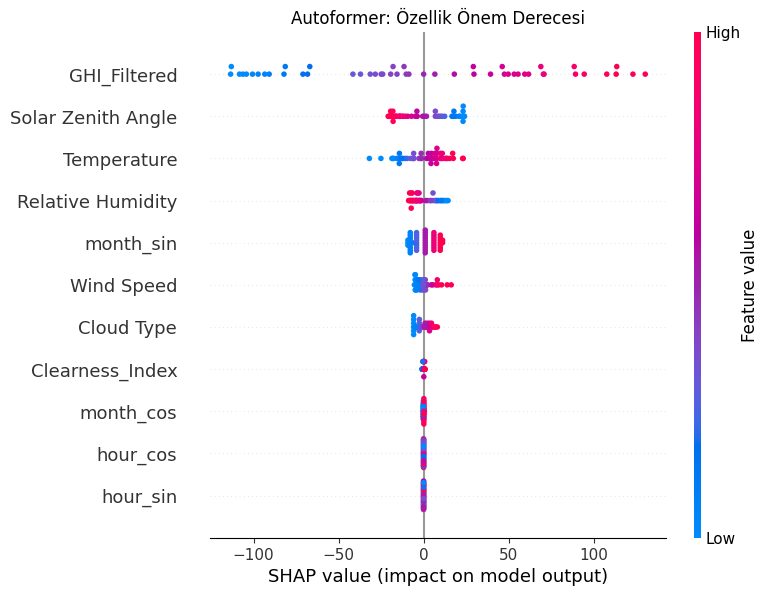

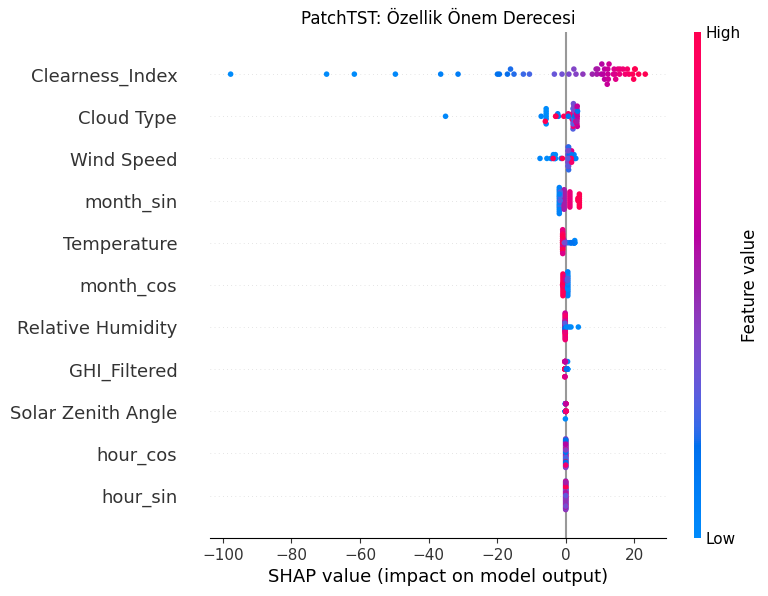

In [6]:
# Autoformer Grafiği
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_auto, background_2d, feature_names=feature_names, show=False)
plt.title("Autoformer: Özellik Önem Derecesi")
plt.savefig('../outputs/plots/autoformer_shap_summary_last.pdf', bbox_inches='tight')
plt.show()

# PatchTST Grafiği
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_patch, background_2d, feature_names=feature_names, show=False)
plt.title("PatchTST: Özellik Önem Derecesi")
plt.savefig('../outputs/plots/patchtst_shap_summary_last.pdf', bbox_inches='tight')
plt.show()